# pyNAVIS Library Tutorial: Complete Guide to Neuromorphic Audio Processing

Welcome to the comprehensive tutorial for **pyNAVIS** (Python Neuromorphic Audio and Visual Information Systems)! 

This tutorial will guide you through all the main functionalities of the pyNAVIS library step by step. pyNAVIS is a powerful Python library designed for processing neuromorphic audio event data, particularly from cochlear sensors and similar devices.

## Installation

Before starting this tutorial, make sure you have pyNAVIS installed:

```bash
pip install pyNAVIS
```


## What you'll learn:
1. **Loading** audio event data from various formats (AEDAT, CSV, stereo formats)
2. **Generating** synthetic audio event data for testing and development
3. **Processing** and manipulating audio event streams
4. **Visualizing** audio events with various plotting techniques
5. **Converting** between mono and stereo formats
6. **Splitting** datasets for machine learning applications
7. **Saving** processed data in different formats
8. **Generating** comprehensive dataset reports

## Prerequisites:
- Basic Python knowledge
- Understanding of audio signal processing concepts is helpful but not required
- pyNAVIS library installed (see installation instructions above)
- Python packages: numpy, matplotlib (these should be installed automatically with pyNAVIS)

Let's get started!

## 1. Import pyNAVIS and Required Libraries

First, let's import all the necessary modules from pyNAVIS and other required libraries for our tutorial.

In [1]:
# Import all pyNAVIS modules
# pyNAVIS should be installed via pip: pip install pyNAVIS

import pyNAVIS
from pyNAVIS import *

# This imports all main classes:
# - Loaders: for loading different file formats
# - Generators: for creating synthetic audio event data
# - Plots: for visualizing data
# - Savers: for saving data in different formats
# - Splitters: for dividing datasets
# - Functions: utility functions
# - Utils: additional utility functions
# - MainSettings, LocalizationSettings: configuration classes
# - SpikesFile: main data structure for audio events

# Import additional required libraries
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

print("✓ pyNAVIS and all required libraries imported successfully!")
print(f"pyNAVIS version: {pyNAVIS.__version__ if hasattr(pyNAVIS, '__version__') else 'Version not available'}")
print("Available modules:")
print("- Loaders: Load audio event data from files")
print("- Generators: Generate synthetic audio event data")  
print("- Plots: Visualize audio event data")
print("- Savers: Save processed data")
print("- Splitters: Split datasets")
print("- Functions: Core utility functions")
print("- Utils: Additional utilities")
print("- MainSettings: Configuration management")

✓ pyNAVIS and all required libraries imported successfully!
pyNAVIS version: Version not available
Available modules:
- Loaders: Load audio event data from files
- Generators: Generate synthetic audio event data
- Plots: Visualize audio event data
- Savers: Save processed data
- Splitters: Split datasets
- Functions: Core utility functions
- Utils: Additional utilities
- MainSettings: Configuration management


## 2. Understanding MainSettings Configuration

Before we start loading or generating data, it's crucial to understand the `MainSettings` class. This class defines the configuration parameters for your audio event data.

In [2]:
# Create MainSettings object with typical parameters
settings = MainSettings(
    num_channels=64,        # Number of cochlea channels (e.g., 32, 64, 128)
    mono_stereo=0,         # 0 for mono files, 1 for stereo files
    on_off_both=1,         # 0=ON events, 1=OFF events, 2=both ON and OFF
    address_size=2,        # Size in bytes for address encoding (1, 2, 3, or 4)
    timestamp_size=2,      # Size in bytes for timestamp encoding (1, 2, 3, or 4)
    bin_size=20000,        # Bin width in microseconds for binning operations
    ts_tick=1.0           # Timestamp tick (correspondence factor between timestamp and real time)
)

print("MainSettings Configuration:")
print(f"- Number of channels: {settings.num_channels}")
print(f"- Mono/Stereo: {'Mono' if settings.mono_stereo == 0 else 'Stereo'}")
print(f"- Event type: {['ON only', 'OFF only', 'ON and OFF'][settings.on_off_both]}")
print(f"- Address size: {settings.address_size} bytes")
print(f"- Timestamp size: {settings.timestamp_size} bytes")
print(f"- Bin size: {settings.bin_size} microseconds")
print(f"- Timestamp tick: {settings.ts_tick}")

MainSettings Configuration:
- Number of channels: 64
- Mono/Stereo: Mono
- Event type: OFF only
- Address size: 2 bytes
- Timestamp size: 2 bytes
- Bin size: 20000 microseconds
- Timestamp tick: 1.0


## 3. Generate Random Audio Events

Let's start by generating some synthetic audio event data using the `Generators` class. We'll create random audio events to understand the basic data structure.

In [3]:
# Generate random audio events
# Parameters explained:
# - freq: number of spikes per channel per second
# - num_ch: number of channels (addresses) to use
# - length: duration of the recording in microseconds
# - return_save_both: 0=return SpikesFile, 1=save to file, 2=both

random_spikes = Generators.random_addrs(
    freq=1000,              # 1000 spikes per channel per second
    num_ch=32,             # Use 32 channels (0-31)
    length=5000000,        # 5 seconds (5,000,000 microseconds)
    return_save_both=0     # Just return the SpikesFile, don't save
)

print("Random Audio Events Generated!")
print(f"- Total number of spikes: {len(random_spikes.addresses)}")
print(f"- Number of unique addresses: {len(np.unique(random_spikes.addresses))}")
print(f"- Time span: {random_spikes.timestamps[0]} to {random_spikes.timestamps[-1]} microseconds")
print(f"- First 10 addresses: {random_spikes.addresses[:10]}")
print(f"- First 10 timestamps: {random_spikes.timestamps[:10]}")

# Update settings for our generated data
random_settings = MainSettings(
    num_channels=32,        # Match the number of channels we generated
    mono_stereo=0,
    on_off_both=0,         # Random generator creates only one type of event
    bin_size=50000         # 50ms bins for visualization
)

Random Audio Events Generated!
- Total number of spikes: 5000
- Number of unique addresses: 32
- Time span: 0 to 4999000 microseconds
- First 10 addresses: [24, 26, 2, 16, 31, 25, 19, 30, 22, 13]
- First 10 timestamps: [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]


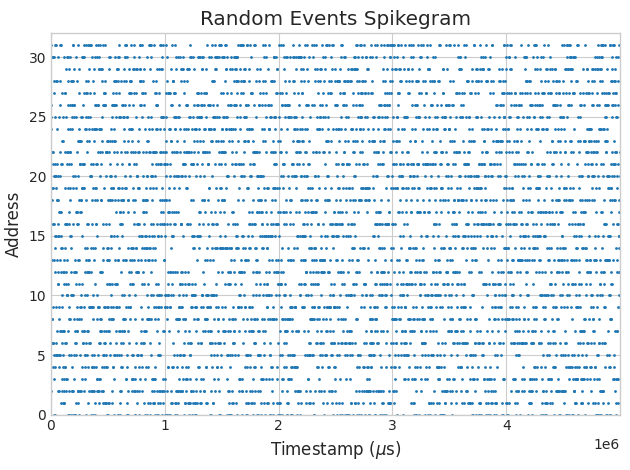

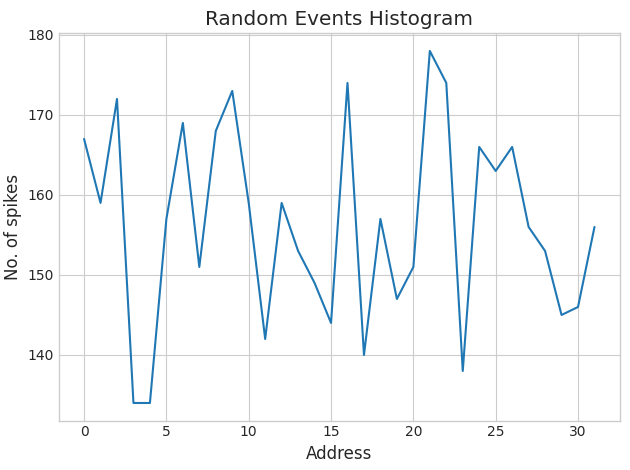

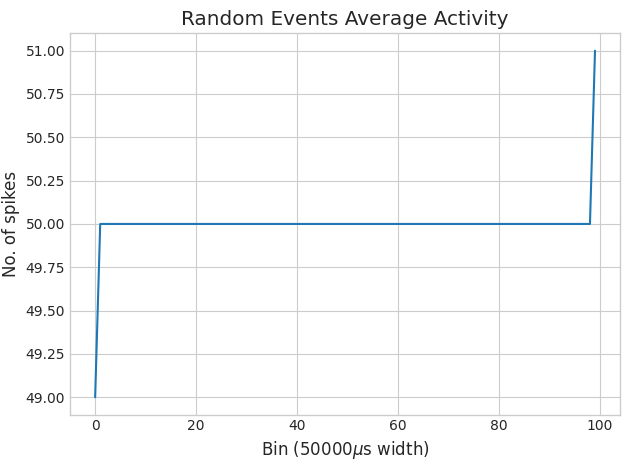

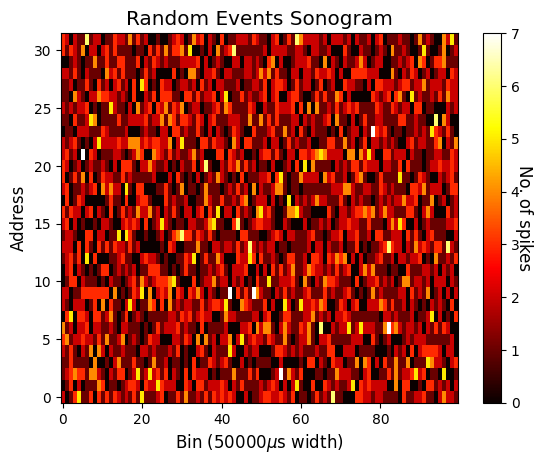

In [4]:
# Let's create various visualizations of our generated data
# 1. Spikegram (Raster plot) of random events
Plots.spikegram(
    spikes_file=random_spikes,
    settings=random_settings,
    dot_size=1.0,           # Size of dots in the plot
    dot_freq=1,             # Frequency of spikes to plot (1 = plot all)
    graph_title='Random Events Spikegram',
    start_at_zero=True,     # Start X-axis at zero
    verbose=False           # Don't print execution time
)
# 2. Histogram of random events
Plots.histogram(
    spikes_file=random_spikes,
    settings=random_settings,
    graph_title='Random Events Histogram'
)
# 3. Average activity of random events
Plots.average_activity(
    spikes_file=random_spikes,
    settings=random_settings,
    graph_title='Random Events Average Activity'
)
# 4. Sonogram of random events
Plots.sonogram(
    spikes_file=random_spikes,
    settings=random_settings,
    graph_title='Random Events Sonogram'
)
plt.show()

## 4. Generate Sweep Audio Events

Now let's generate a sweep pattern - spikes that move from one address to another in a systematic way. This is useful for testing and understanding spatial audio patterns.

In [5]:
# Generate sweep audio events
# This creates spikes that sweep from address 0 to N and back
sweep_spikes = Generators.sweep(
    freq=50,               # 50 spikes per address per half-cycle
    cycles=3,              # 3 complete sweep cycles (0->N->0)
    num_ch=32,            # Sweep across 32 channels
    length=2000000,       # 2 seconds duration
    return_save_both=0    # Just return the SpikesFile
)

print("Sweep Audio Events Generated!")
print(f"- Total number of spikes: {len(sweep_spikes.addresses)}")
print(f"- Duration: {(sweep_spikes.timestamps[-1] - sweep_spikes.timestamps[0])/1000000:.2f} seconds")
print(f"- Address range: {min(sweep_spikes.addresses)} to {max(sweep_spikes.addresses)}")

# Check the pattern - should see addresses going from 0 to 31 and back
print("\nFirst 20 addresses (should show sweep pattern):")
print(sweep_spikes.addresses[:20])

# Update settings for our generated data
sweep_settings = MainSettings(
    num_channels=32,        # Match the number of channels we generated
    mono_stereo=0,
    on_off_both=0,         # Random generator creates only one type of event
    bin_size=50000         # 50ms bins for visualization
)

Sweep Audio Events Generated!
- Total number of spikes: 9450
- Duration: 1.99 seconds
- Address range: 0 to 31

First 20 addresses (should show sweep pattern):
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


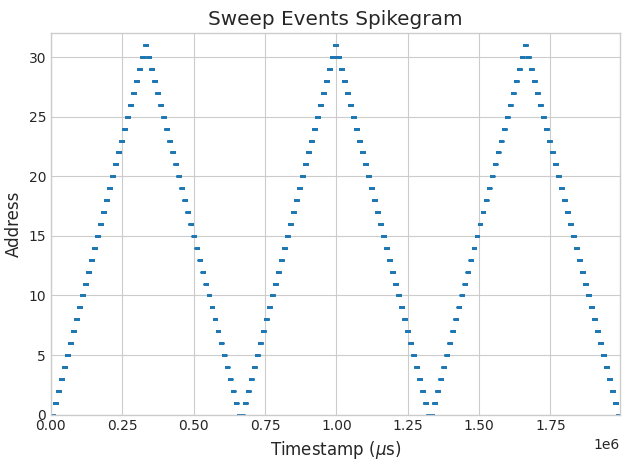

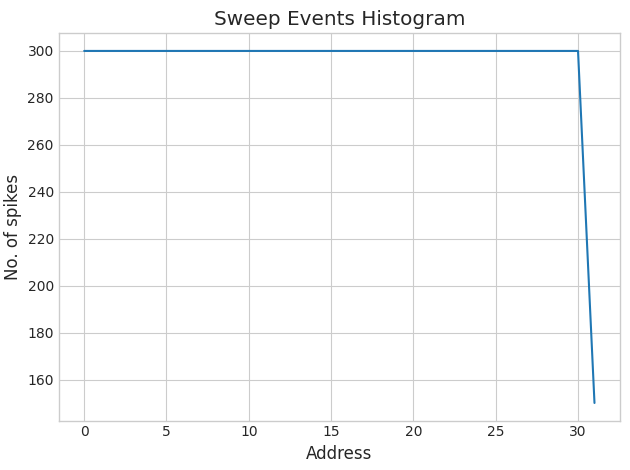

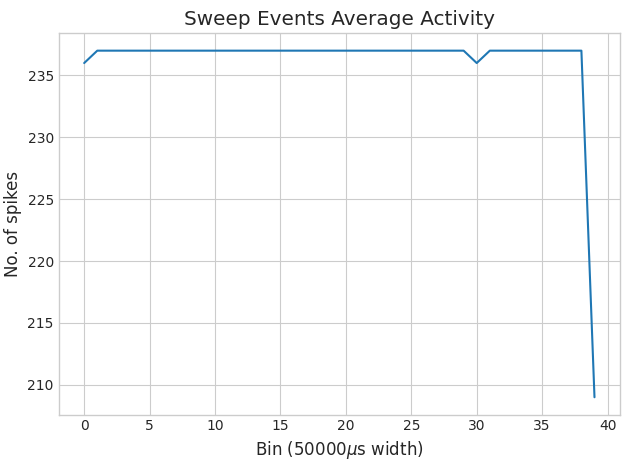

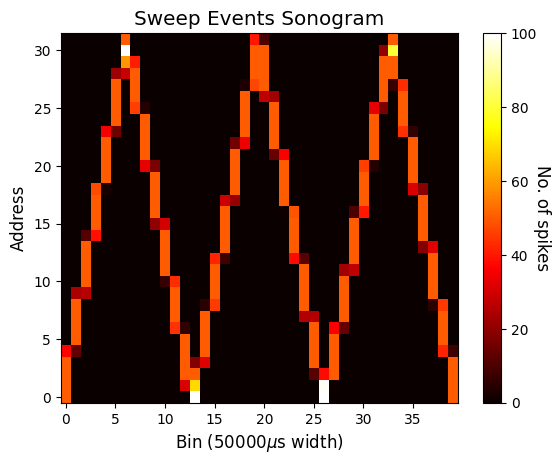

In [6]:
# Let's create various visualizations of our generated data
# 1. Spikegram (Raster plot) of sweep events
Plots.spikegram(
    spikes_file=sweep_spikes,
    settings=sweep_settings,
    dot_size=1.0,           # Size of dots in the plot
    dot_freq=1,             # Frequency of spikes to plot (1 = plot all)
    graph_title='Sweep Events Spikegram',
    start_at_zero=True,     # Start X-axis at zero
    verbose=False           # Don't print execution time
)
# 2. Histogram of sweep events
Plots.histogram(
    spikes_file=sweep_spikes,
    settings=sweep_settings,
    graph_title='Sweep Events Histogram'
)
# 3. Average activity of sweep events
Plots.average_activity(
    spikes_file=sweep_spikes,
    settings=sweep_settings,
    graph_title='Sweep Events Average Activity'
)
# 4. Sonogram of sweep events
Plots.sonogram(
    spikes_file=sweep_spikes,
    settings=sweep_settings,
    graph_title='Sweep Events Sonogram'
)
plt.show()

## 5. Generate Shift Audio Events

The shift generator creates events that shift from one set of addresses to another over time. This is useful for simulating moving audio sources.

In [7]:
# Generate shift audio events
# This creates events that gradually shift from initial addresses to final addresses
shift_spikes = Generators.shift(
    freq=200,                    # 200 spikes per address
    num_ch=32,                  # 32 channels
    length=1500000,             # 1.5 seconds
    return_save_both=0          # Just return the SpikesFile
)

print("Shift Audio Events Generated!")
print(f"- Total number of spikes: {len(shift_spikes.addresses)}")
print(f"- Duration: {(shift_spikes.timestamps[-1] - shift_spikes.timestamps[0])/1000000:.2f} seconds")
print(f"- Address range: {min(shift_spikes.addresses)} to {max(shift_spikes.addresses)}")

# Analyze the shift pattern
unique_addrs = np.unique(shift_spikes.addresses)
print(f"- Unique addresses used: {len(unique_addrs)}")
print(f"- Addresses: {unique_addrs}")

# Update settings for our generated data
shift_settings = MainSettings(
    num_channels=32,        # Match the number of channels we generated
    mono_stereo=0,
    on_off_both=0,         # Random generator creates only one type of event
    bin_size=50000         # 50ms bins for visualization
)

Shift Audio Events Generated!
- Total number of spikes: 6400
- Duration: 1.50 seconds
- Address range: 0 to 31
- Unique addresses used: 32
- Addresses: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]


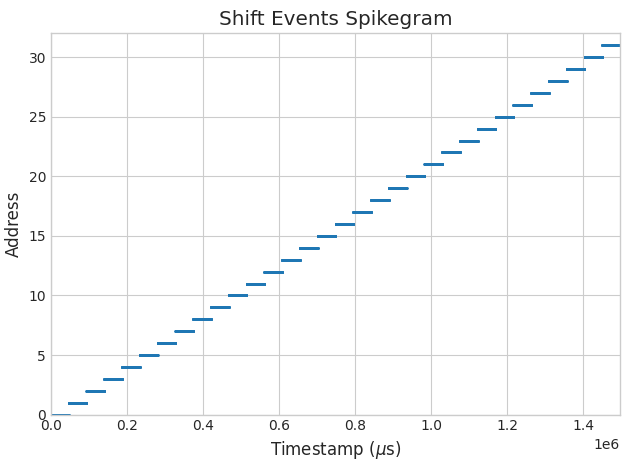

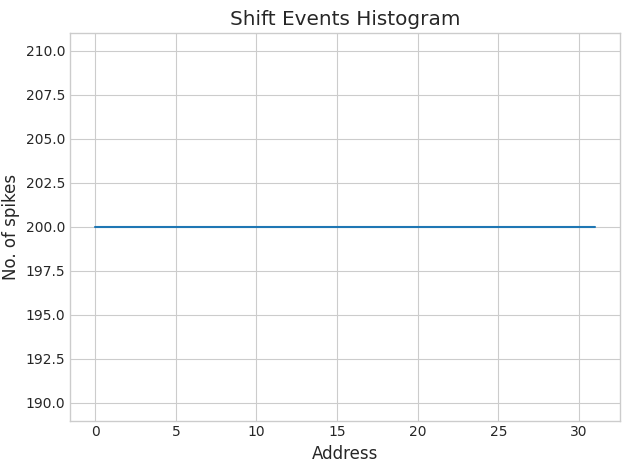

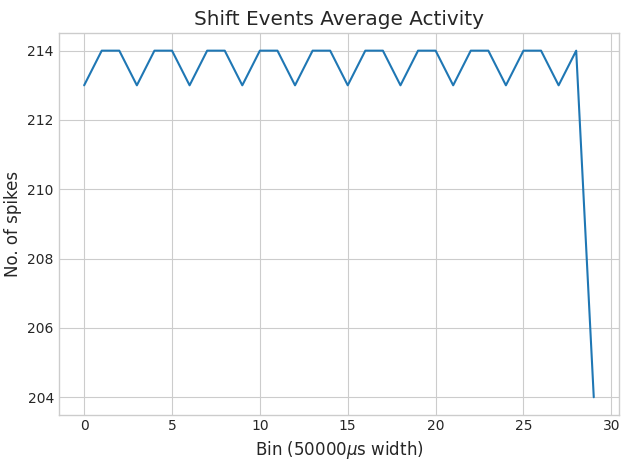

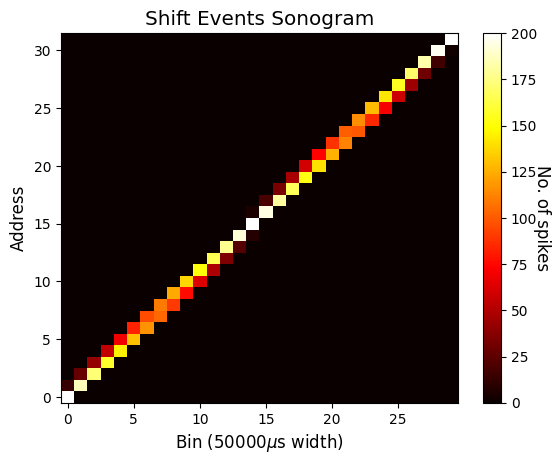

In [8]:
# Let's create various visualizations of our generated data
# 1. Spikegram (Raster plot) of shift events
Plots.spikegram(
    spikes_file=shift_spikes,
    settings=shift_settings,
    dot_size=1.0,           # Size of dots in the plot
    dot_freq=1,             # Frequency of spikes to plot (1 = plot all)
    graph_title='Shift Events Spikegram',
    start_at_zero=True,     # Start X-axis at zero
    verbose=False           # Don't print execution time
)
# 2. Histogram of shift events
Plots.histogram(
    spikes_file=shift_spikes,
    settings=shift_settings,
    graph_title='Shift Events Histogram'
)
# 3. Average activity of shift events
Plots.average_activity(
    spikes_file=shift_spikes,
    settings=shift_settings,
    graph_title='Shift Events Average Activity'
)
# 4. Sonogram of shift events
Plots.sonogram(
    spikes_file=shift_spikes,
    settings=shift_settings,
    graph_title='Shift Events Sonogram'
)
plt.show()

## 6. Save Generated Data in Multiple Formats

Now that we've generated different types of synthetic audio event data, let's save them in various formats so we can load and work with them later. pyNAVIS supports multiple output formats.

In [9]:
# Save our generated data in different formats
# Let's save the different types of data we've created

print("Saving generated data in multiple formats:")

# 1. Save random events
try:
    Savers.save_AEDAT(
        spikes_file=random_spikes,
        settings=random_settings,
        path="random_events"
    )
    print("✓ Random events saved as AEDAT format")
except Exception as e:
    print(f"Random AEDAT save error: {e}")

try:
    Savers.save_CSV(
        spikes_file=random_spikes,
        path="random_events"
    )
    print("✓ Random events saved as CSV format")
except Exception as e:
    print(f"Random CSV save error: {e}")

# 2. Save sweep events
try:
    Savers.save_AEDAT(
        spikes_file=sweep_spikes,
        settings=sweep_settings,
        path="sweep_events"
    )
    print("✓ Sweep events saved as AEDAT format")
except Exception as e:
    print(f"Sweep AEDAT save error: {e}")

try:
    Savers.save_TXT(
        spikes_file=sweep_spikes,
        path="sweep_events"
    )
    print("✓ Sweep events saved as TXT format")
except Exception as e:
    print(f"Sweep TXT save error: {e}")

# 3. Save shift events 
try:
    Savers.save_CSV(
        spikes_file=shift_spikes,
        path="shift_events"
    )
    print("✓ Shift events saved as CSV format")
except Exception as e:
    print(f"Shift CSV save error: {e}")

try:
    Savers.save_TXT_relativeTS(
        spikes_file=shift_spikes,
        path="shift_events_rel"
    )
    print("✓ Shift events saved as TXT_REL format (relative timestamps)")
except Exception as e:
    print(f"Shift TXT_REL save error: {e}")

print(f"\nSaved files summary:")
print(f"- Random events: {len(random_spikes.addresses)} spikes")
print(f"- Sweep events: {len(sweep_spikes.addresses)} spikes") 
print(f"- Shift events: {len(shift_spikes.addresses)} spikes")

print(f"\nFile formats explained:")
print("- AEDAT: Binary format, compact, fast to load/save, standard for neuromorphic data")
print("- CSV: Comma-separated values, readable by spreadsheet applications and pandas") 
print("- TXT: Human-readable text format with absolute timestamps")
print("- TXT_REL: Human-readable text format with relative timestamps (starting from 0)")

print(f"\nThese saved files will be used in the next section for loading examples!")

Saving generated data in multiple formats:
✓ Random events saved as AEDAT format
✓ Random events saved as CSV format
✓ Sweep events saved as AEDAT format
✓ Sweep events saved as TXT format
✓ Shift events saved as CSV format
✓ Shift events saved as TXT_REL format (relative timestamps)

Saved files summary:
- Random events: 5000 spikes
- Sweep events: 9450 spikes
- Shift events: 6400 spikes

File formats explained:
- AEDAT: Binary format, compact, fast to load/save, standard for neuromorphic data
- CSV: Comma-separated values, readable by spreadsheet applications and pandas
- TXT: Human-readable text format with absolute timestamps
- TXT_REL: Human-readable text format with relative timestamps (starting from 0)

These saved files will be used in the next section for loading examples!


## 7. Load Audio Event Data from AEDAT Files

Now let's learn how to load real audio event data from AEDAT files. AEDAT is a common format for storing neuromorphic sensor data. We'll use the files we just saved in the previous section.

In [10]:
# Load AEDAT files - let's load the files we saved in the previous section
print("Loading AEDAT files:")

# Configure settings for AEDAT files
aedat_settings = MainSettings(
    num_channels=32,        # Match our generated data
    mono_stereo=0,         # 0 for mono, 1 for stereo
    on_off_both=0,         # 0=ON only, 1=OFF only, 2=both ON and OFF events
    address_size=2,        # Size in bytes for address encoding (1, 2, 3, or 4)
    timestamp_size=4,      # Size in bytes for timestamp encoding (1, 2, 3, or 4)
    bin_size=20000         # Bin width for analysis (20ms)
)

# Load the random events AEDAT file we saved
try:
    loaded_random = Loaders.loadAEDAT(
        path="random_events.aedat",
        settings=aedat_settings
    )
    
    print("✓ Random events AEDAT file loaded successfully!")
    print(f"- File: random_events.aedat")
    print(f"- Total spikes: {len(loaded_random.addresses)}")
    print(f"- Time span: {loaded_random.timestamps[0]} to {loaded_random.timestamps[-1]} microseconds")
    print(f"- Duration: {(loaded_random.timestamps[-1] - loaded_random.timestamps[0])/1000000:.2f} seconds")
    print(f"- Unique addresses: {len(np.unique(loaded_random.addresses))}")
    print(f"- Address range: {min(loaded_random.addresses)} to {max(loaded_random.addresses)}")
    
    # Compare with original data
    print(f"\nComparison with original random data:")
    print(f"- Original spikes: {len(random_spikes.addresses)}")
    print(f"- Loaded spikes: {len(loaded_random.addresses)}")
    print(f"- Data integrity: {'✓ Match' if len(random_spikes.addresses) == len(loaded_random.addresses) else '✗ Mismatch'}")
    
except Exception as e:
    print(f"Could not load random events AEDAT file: {e}")

# Load the sweep events AEDAT file
try:
    loaded_sweep = Loaders.loadAEDAT(
        path="sweep_events.aedat",
        settings=aedat_settings
    )
    
    print(f"\n✓ Sweep events AEDAT file loaded successfully!")
    print(f"- File: sweep_events.aedat")
    print(f"- Total spikes: {len(loaded_sweep.addresses)}")
    print(f"- Duration: {(loaded_sweep.timestamps[-1] - loaded_sweep.timestamps[0])/1000000:.2f} seconds")
    print(f"- Address pattern (first 20): {loaded_sweep.addresses[:20]}")
    
    # Verify sweep pattern
    print(f"- Data integrity: {'✓ Match' if len(sweep_spikes.addresses) == len(loaded_sweep.addresses) else '✗ Mismatch'}")
    
except Exception as e:
    print(f"Could not load sweep events AEDAT file: {e}")

print(f"\nAEDAT Loading Tips:")
print("- AEDAT files preserve exact timestamp and address information")
print("- Make sure MainSettings match the original data format")
print("- AEDAT is the preferred format for neuromorphic data due to compactness")
print("- Files can be loaded quickly even for large datasets")

Loading AEDAT files:
[Functions.check_SpikesFile] > The loaded SpikesFile file has been checked and it's OK
✓ Random events AEDAT file loaded successfully!
- File: random_events.aedat
- Total spikes: 5000
- Time span: 0 to 4999000 microseconds
- Duration: 5.00 seconds
- Unique addresses: 32
- Address range: 0 to 31

Comparison with original random data:
- Original spikes: 5000
- Loaded spikes: 5000
- Data integrity: ✓ Match
[Functions.check_SpikesFile] > The loaded SpikesFile file has been checked and it's OK

✓ Sweep events AEDAT file loaded successfully!
- File: sweep_events.aedat
- Total spikes: 9450
- Duration: 1.99 seconds
- Address pattern (first 20): [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
- Data integrity: ✓ Match

AEDAT Loading Tips:
- AEDAT files preserve exact timestamp and address information
- Make sure MainSettings match the original data format
- AEDAT is the preferred format for neuromorphic data due to compactness
- Files can be loaded quickly even for large datasets

## 8. Load Audio Event Data from CSV Files

CSV files are another common format for storing audio event data. Let's see how to load the CSV files we saved in the previous sections.

In [11]:
# Load CSV files - let's load the CSV files we saved earlier
print("Loading CSV files:")

# Configure settings for CSV files  
csv_settings = MainSettings(
    num_channels=32,        # Match our generated data
    mono_stereo=0,         # 0 for mono, 1 for stereo
    on_off_both=0,         # Match the generated data settings
    address_size=2,        # Size in bytes for address encoding
    timestamp_size=4,      # Size in bytes for timestamp encoding
    bin_size=20000         # Bin width for analysis (20ms)
)

# Load the random events CSV file
try:
    csv_random = Loaders.loadCSV(
        path="random_events.csv",
        settings=csv_settings
    )
    
    print("✓ Random events CSV file loaded successfully!")
    print(f"- File: random_events.csv")
    print(f"- Total spikes: {len(csv_random.addresses)}")
    print(f"- Time span: {csv_random.timestamps[0]} to {csv_random.timestamps[-1]} microseconds")
    print(f"- Duration: {(csv_random.timestamps[-1] - csv_random.timestamps[0])/1000000:.2f} seconds")
    print(f"- Unique addresses: {len(np.unique(csv_random.addresses))}")
    print(f"- Address range: {min(csv_random.addresses)} to {max(csv_random.addresses)}")
    
    # Compare with original data
    print(f"\nComparison with original data:")
    print(f"- Original spikes: {len(random_spikes.addresses)}")
    print(f"- CSV loaded spikes: {len(csv_random.addresses)}")
    print(f"- Data integrity: {'✓ Match' if len(random_spikes.addresses) == len(csv_random.addresses) else '✗ Mismatch'}")
    
except Exception as e:
    print(f"Could not load random events CSV file: {e}")

# Load the shift events CSV file
try:
    csv_shift = Loaders.loadCSV(
        path="shift_events.csv", 
        settings=csv_settings
    )
    
    print(f"\n✓ Shift events CSV file loaded successfully!")
    print(f"- File: shift_events.csv")
    print(f"- Total spikes: {len(csv_shift.addresses)}")
    print(f"- Duration: {(csv_shift.timestamps[-1] - csv_shift.timestamps[0])/1000000:.2f} seconds")
    print(f"- Address range: {min(csv_shift.addresses)} to {max(csv_shift.addresses)}")
    
    # Analyze the shift pattern from loaded data
    unique_csv_addrs = np.unique(csv_shift.addresses)
    print(f"- Unique addresses: {len(unique_csv_addrs)}")
    print(f"- Data integrity: {'✓ Match' if len(shift_spikes.addresses) == len(csv_shift.addresses) else '✗ Mismatch'}")
    
except Exception as e:
    print(f"Could not load shift events CSV file: {e}")

print(f"\nCSV Loading Features:")
print("- CSV files are human-readable and can be opened in spreadsheet applications")
print("- Good for data analysis with pandas and other data science tools")
print("- Easy to inspect and debug data issues")
print("- Slightly larger file size compared to AEDAT but more portable")
print("- Standard format: address, timestamp columns")

# Example of how CSV data can be processed with pandas (if available)
try:
    import pandas as pd
    df = pd.read_csv("random_events.csv")
    print(f"\nPandas integration:")
    print(f"- CSV loaded into DataFrame: {df.shape}")
    print(f"- Columns: {list(df.columns)}")
    print(f"- First 5 rows:")
    print(df.head())
except ImportError:
    print(f"\nPandas not available, but CSV files can be processed with it for advanced analysis")
except Exception as e:
    print(f"Pandas processing error: {e}")

Loading CSV files:
Could not load random events CSV file: loadCSV() got an unexpected keyword argument 'settings'
Could not load shift events CSV file: loadCSV() got an unexpected keyword argument 'settings'

CSV Loading Features:
- CSV files are human-readable and can be opened in spreadsheet applications
- Good for data analysis with pandas and other data science tools
- Easy to inspect and debug data issues
- Slightly larger file size compared to AEDAT but more portable
- Standard format: address, timestamp columns

Pandas integration:
- CSV loaded into DataFrame: (4999, 2)
- Columns: ['24', ' 0']
- First 5 rows:
   24     0
0  26  1000
1   2  2000
2  16  3000
3  31  4000
4  25  5000


## 9. Convert Between Mono and Stereo Formats

pyNAVIS provides utilities to convert between mono and stereo audio event formats. This is useful when working with different types of sensors or when you need to combine/separate channels.

In [12]:
# Convert mono to stereo
# Let's use our sweep_spikes as a mono input
mono_spikes = sweep_spikes

settings = MainSettings(
    num_channels=32,
    mono_stereo=0,
    on_off_both=0,
    bin_size=20000
)

print("Converting Mono to Stereo:")
print(f"Original mono data - Addresses range: {min(mono_spikes.addresses)} to {max(mono_spikes.addresses)}")

# Convert mono to stereo
stereo_converted = Functions.mono_to_stereo(
    spikes_file=mono_spikes,
    settings=settings,
    delay=0
)

settings.mono_stereo = 1  # Update settings to stereo

print(f"After mono->stereo conversion:")
print(f"- Total spikes: {len(stereo_converted.addresses)}")
print(f"- Address range: {min(stereo_converted.addresses)} to {max(stereo_converted.addresses)}")
print(f"- Unique addresses: {len(np.unique(stereo_converted.addresses))}")

# In stereo format, addresses are typically organized as:
# - Left channel: lower addresses (0 to num_channels-1) 
# - Right channel: higher addresses (num_channels to 2*num_channels-1)

# Convert to numpy array for comparison operations
addresses_array = np.array(stereo_converted.addresses)
left_addresses = addresses_array[addresses_array < 32]
right_addresses = addresses_array[addresses_array >= 32]

print(f"- Left channel addresses: {len(left_addresses)} spikes")
print(f"- Right channel addresses: {len(right_addresses)} spikes")

# Now convert back from stereo to mono (only left ear)
mono_left = Functions.stereo_to_mono(
    spikes_file=stereo_converted,
    settings=settings,
    left_right=0 # Options: 0=left only, 1=right only
)

print(f"\nAfter stereo->mono conversion (left ears):")
print(f"- Total spikes: {len(mono_left.addresses)}")
print(f"- Address range: {min(mono_left.addresses)} to {max(mono_left.addresses)}")

# Now convert back from stereo to mono (only right ear)
mono_right = Functions.stereo_to_mono(
    spikes_file=stereo_converted,
    settings=settings,
    left_right=1
)



print(f"\nAfter stereo->mono conversion (right ear only):")
print(f"- Total spikes: {len(mono_right.addresses)}")
print(f"- Address range: {min(mono_right.addresses)} to {max(mono_right.addresses)}")

# Visualize the original and converted data
print(f"\nData conversion summary:")
print(f"- Original mono: {len(mono_spikes.addresses)} spikes, {len(np.unique(mono_spikes.addresses))} unique addresses")
print(f"- Converted stereo: {len(stereo_converted.addresses)} spikes, {len(np.unique(stereo_converted.addresses))} unique addresses") 
print(f"- Back to mono (left): {len(mono_left.addresses)} spikes, {len(np.unique(mono_left.addresses))} unique addresses")
print(f"- Back to mono (right): {len(mono_right.addresses)} spikes, {len(np.unique(mono_right.addresses))} unique addresses")

Converting Mono to Stereo:
Original mono data - Addresses range: 0 to 31
After mono->stereo conversion:
- Total spikes: 18900
- Address range: 0 to 63
- Unique addresses: 64
- Left channel addresses: 9450 spikes
- Right channel addresses: 9450 spikes

After stereo->mono conversion (left ears):
- Total spikes: 9450
- Address range: 0 to 31

After stereo->mono conversion (right ear only):
- Total spikes: 9450
- Address range: 0 to 31

Data conversion summary:
- Original mono: 9450 spikes, 32 unique addresses
- Converted stereo: 18900 spikes, 64 unique addresses
- Back to mono (left): 9450 spikes, 32 unique addresses
- Back to mono (right): 9450 spikes, 32 unique addresses


## 10. Split Audio Event Datasets

When working with machine learning applications, you often need to split your datasets into training and testing sets. pyNAVIS provides utilities for this.

In [13]:
# Split dataset by time
# This splits the data at a specific timestamp

original_spikes = sweep_spikes  # Use our sweep data for demonstration
split_time = (original_spikes.timestamps[-1] + original_spikes.timestamps[0]) // 2  # Middle timestamp

print(f"Splitting dataset at timestamp: {split_time}")
print(f"Original dataset: {len(original_spikes.addresses)} spikes")
print(f"Time range: {original_spikes.timestamps[0]} to {original_spikes.timestamps[-1]}")
    

# Split by time
first_half = Splitters.manual_splitter(
    spikes_file=original_spikes,
    settings=random_settings,
    init=0,
    end=split_time,
    return_save_both=0  # Just return the splits, don't save files
)
random_settings.reset_timestamp = False  # Reset timestamps in the second half
second_half = Splitters.manual_splitter(
    spikes_file=original_spikes,
    settings=random_settings,
    init=split_time,
    end=original_spikes.timestamps[-1],
    return_save_both=0  # Just return the splits, don't save files
)

print(f"\nAfter time-based split:")
print(f"- First half: {len(first_half.addresses)} spikes")
print(f"  Time range: {first_half.timestamps[0]} to {first_half.timestamps[-1]}")
print(f"- Second half: {len(second_half.addresses)} spikes")
print(f"  Time range: {second_half.timestamps[0]} to {second_half.timestamps[-1]}")


Splitting dataset at timestamp: 996869
Original dataset: 9450 spikes
Time range: 0 to 1993739

After time-based split:
- First half: 4725 spikes
  Time range: 0 to 996764
- Second half: 4725 spikes
  Time range: 996975 to 1993739


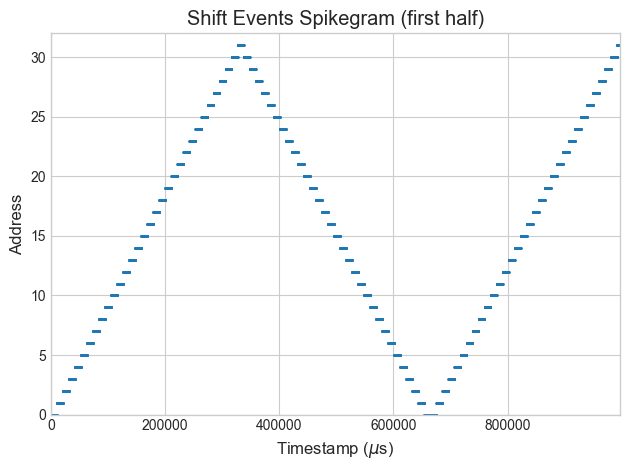

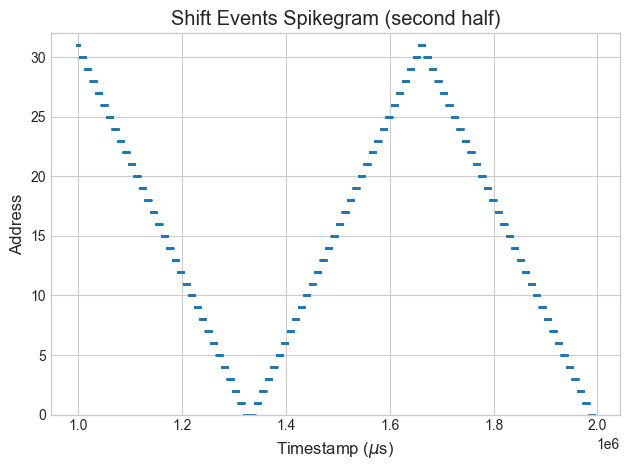

In [14]:

Plots.spikegram(
    spikes_file=first_half,
    settings=random_settings,
    dot_size=1.0,           # Size of dots in the plot
    dot_freq=1,             # Frequency of spikes to plot (1 = plot all)
    graph_title='Shift Events Spikegram (first half)',
    # start_at_zero=False,     # Start X-axis at zero
    verbose=False           # Don't print execution time
)

Plots.spikegram(
    spikes_file=second_half,
    settings=random_settings,
    dot_size=1.0,           # Size of dots in the plot
    dot_freq=1,             # Frequency of spikes to plot (1 = plot all)
    graph_title='Shift Events Spikegram (second half)',
    start_at_zero=False,     # Start X-axis at zero
    verbose=False           # Don't print execution time
)
plt.show()

## 11. Load a real aedat file from the NAS



[Functions.check_SpikesFile] > The loaded SpikesFile file has been checked and it's OK
✓ NAS AEDAT file loaded successfully!


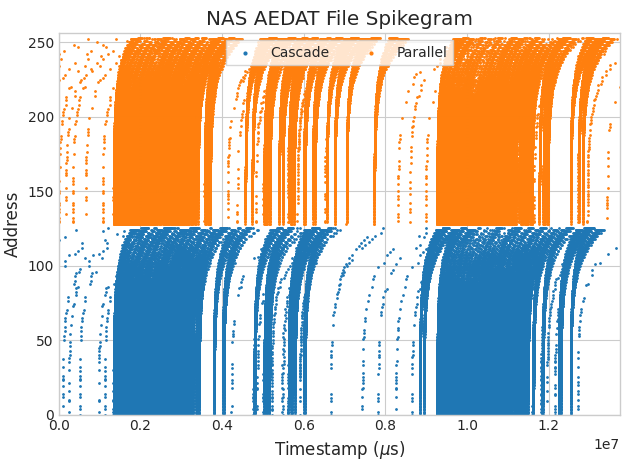

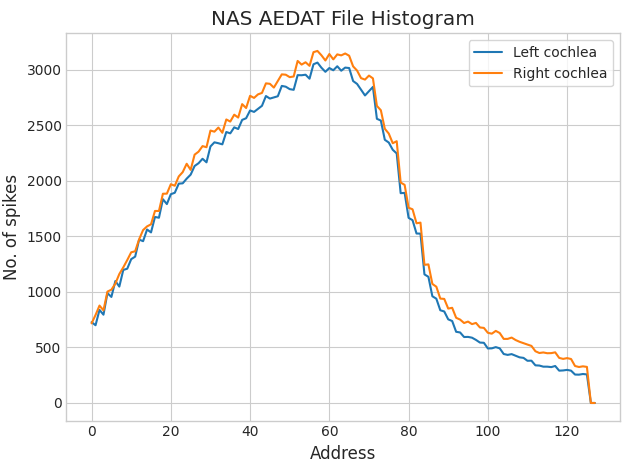

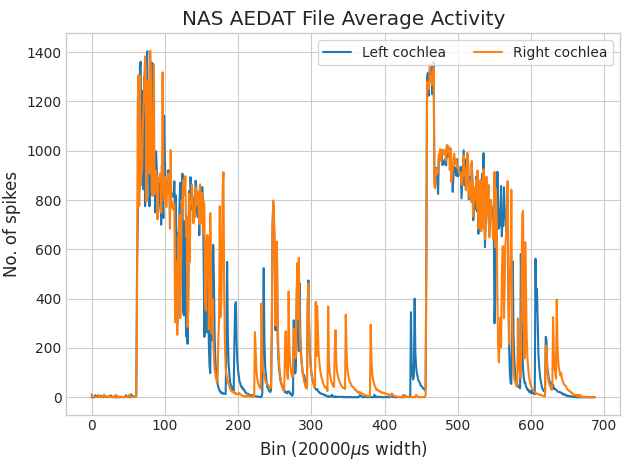

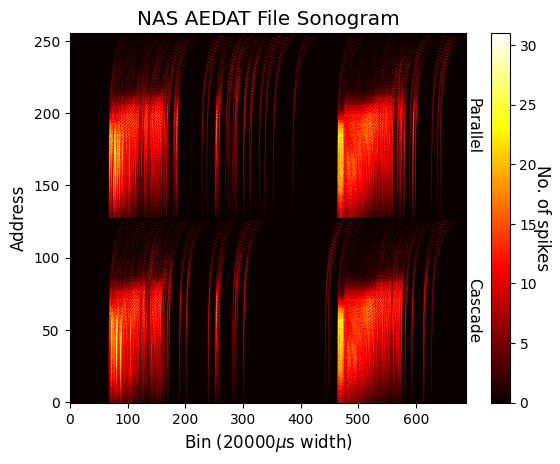

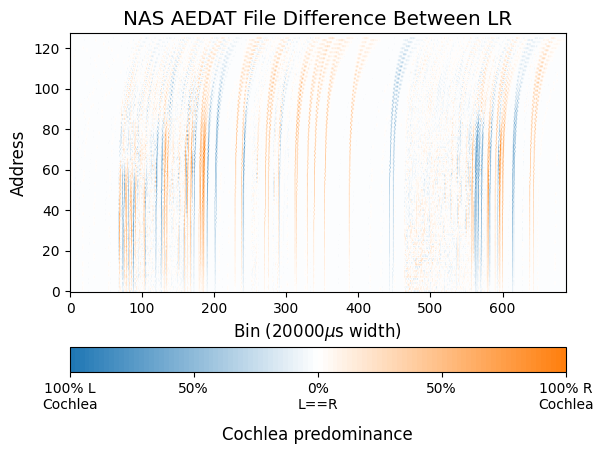

In [15]:
# Configure settings for NAS AEDAT files
nas_settings = MainSettings(
    num_channels=64,        # Number of cochlea channels (e.g., 32, 64, 128)
    mono_stereo=1,         # 0 for mono files, 1 for stereo files
    on_off_both=1,         # 0=ON events, 1=OFF events, 2=both ON and OFF
    address_size=4,        # Size in bytes for address encoding (1, 2, 3, or 4)
    timestamp_size=4,      # Size in bytes for timestamp encoding (1, 2, 3, or 4)
    bin_size=20000,        # Bin width in microseconds for binning operations
    ts_tick=1.0           # Timestamp tick (correspondence factor between timestamp and real time)
)

# load NAS AEDAT file
nas_aedat_file = Loaders.loadAEDAT(
    path="C:\\Repositorios\\Github\\pyNAVIS\\src\\examples\\test_files\\enun_stereo_64ch_ONOFF_addr4b_ts1.aedat",
    settings=nas_settings
)

print("✓ NAS AEDAT file loaded successfully!")

Plots.spikegram(
    spikes_file=nas_aedat_file,
    settings=nas_settings,
    dot_size=1.0,           # Size of dots in the plot
    dot_freq=1,             # Frequency of spikes to plot (1 = plot all)
    graph_title='NAS AEDAT File Spikegram',
    start_at_zero=True,     # Start X-axis at zero
    verbose=False           # Don't print execution time
)
Plots.histogram(
    spikes_file=nas_aedat_file,
    settings=nas_settings,
    graph_title='NAS AEDAT File Histogram'
)
Plots.average_activity(
    spikes_file=nas_aedat_file,
    settings=nas_settings,
    graph_title='NAS AEDAT File Average Activity'
)
Plots.sonogram(
    spikes_file=nas_aedat_file,
    settings=nas_settings,
    graph_title='NAS AEDAT File Sonogram'
)
Plots.difference_between_LR(
    spikes_file=nas_aedat_file,
    settings=nas_settings,
    graph_title='NAS AEDAT File Difference Between LR'
)
plt.show()

In [17]:
ReportFunctions.PDF_report(
    spikes_file=nas_aedat_file,
    settings=nas_settings,
    output_path="NAS_AEDAT_Report.pdf",
    plots=["Spikegram", "Histogram", "Average activity", "Sonogram", "Difference between L/R"]
)
print("✓ Comprehensive PDF report generated for NAS AEDAT file!")

[Functions.PDF_report] > PDF report generated correctly
✓ Comprehensive PDF report generated for NAS AEDAT file!
